In [31]:
from pathlib import Path
from PIL import Image
import hashlib
from torchvision import datasets
import matplotlib.pyplot as plt
from collections import Counter
import random
import os
from torchvision import datasets
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset
random.seed(42)

# *Corrupted Image*

In [32]:
def find_corrupted_images(folder_path):
    corrupted_images = []

    for image_path in Path(folder_path).rglob("*"):
        if image_path.is_file():
            try:
                with Image.open(image_path) as image:
                    image.verify()
            except Exception:
                corrupted_images.append(image_path)

    return corrupted_images

In [33]:
train_path = Path("../data/train")
ood_validation_path = Path("../data/ood_validation")

print("Train path:")
print(train_path.resolve())
print("Exists:", train_path.exists())

print("\nood_validation path:")
print(ood_validation_path.resolve())
print("Exists:", ood_validation_path.exists())

Train path:
G:\AiCourseMaktab\Projects\Traffic Vehcles\data\train
Exists: True

ood_validation path:
G:\AiCourseMaktab\Projects\Traffic Vehcles\data\ood_validation
Exists: True


In [34]:


image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

count_train = 0
count_ood_validation = 0

for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.lower().endswith(tuple(image_extensions)):
            count_train += 1


for root, dirs, files in os.walk(ood_validation_path):
    for file in files:
        if file.lower().endswith(tuple(image_extensions)):
            count_ood_validation += 1
            
print("Total train images:", count_train)
print("Total ood images:", count_ood_validation)

Total train images: 3651
Total ood images: 635


In [35]:


train_corrupted = find_corrupted_images(train_path)
ood_validation_corrupted = find_corrupted_images(ood_validation_path)

print("Train corrupted:", len(train_corrupted))
print("ood_validation corrupted:", len(ood_validation_corrupted))

print("\nTrain corrupted files:")
for path in train_corrupted:
    print(path)

print("\nood validation corrupted files:")
for path in ood_validation_corrupted:
    print(path)

Train corrupted: 0
ood_validation corrupted: 0

Train corrupted files:

ood validation corrupted files:


# *Duplicate Image*

In [36]:
def get_file_hash(file_path):
    hash_md5 = hashlib.md5()

    with open(file_path, "rb") as file:
        for chunk in iter(lambda: file.read(4096), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()


def find_duplicates(folder_path):
    hashes = {}
    duplicates = []

    for image_path in folder_path.rglob("*"):
        
        if image_path.is_file():

            try:
                file_hash = get_file_hash(image_path)

                if file_hash in hashes:
                    duplicates.append(
                        (image_path, hashes[file_hash])
                    )
                else:
                    hashes[file_hash] = image_path

            except Exception as e:
                print("ERROR:", image_path)
                print(e)

    return duplicates




In [37]:

train_duplicates = find_duplicates(train_path)

print("Number of train duplicates:", len(train_duplicates))
if len(train_duplicates) > 0 :
    print(train_duplicates)


ood_validation_duplicates = find_duplicates(ood_validation_path)

print("Number of ood_validation duplicates:", len(ood_validation_duplicates))

Number of train duplicates: 0
Number of ood_validation duplicates: 0


# *Train ood_validation Duplicate Image*

In [38]:
def find_train_ood_validation_duplicates(train_path, ood_validation_path):

    train_hashes = {}

    for image_path in train_path.rglob("*"):

        if image_path.is_file():

            try:
                file_hash = get_file_hash(image_path)
                train_hashes[file_hash] = image_path

            except Exception:
                pass

    duplicates = []

    for image_path in ood_validation_path.rglob("*"):

        if image_path.is_file():

            try:
                file_hash = get_file_hash(image_path)

                if file_hash in train_hashes:
                    duplicates.append(
                        (image_path, train_hashes[file_hash])
                    )

            except Exception as e:
                print("ERROR:", image_path)
                print (e)


    return duplicates

['ambulance', 'autobus', 'kamyun', 'kamyunet', 'minibus', 'savari', 'taxi', 'vanet']
ambulance 402 images (11.01%)
autobus 520 images (14.24%)
kamyun 480 images (13.15%)
kamyunet 552 images (15.12%)
minibus 461 images (12.63%)
savari 552 images (15.12%)
taxi 536 images (14.68%)
vanet 148 images (4.05%)


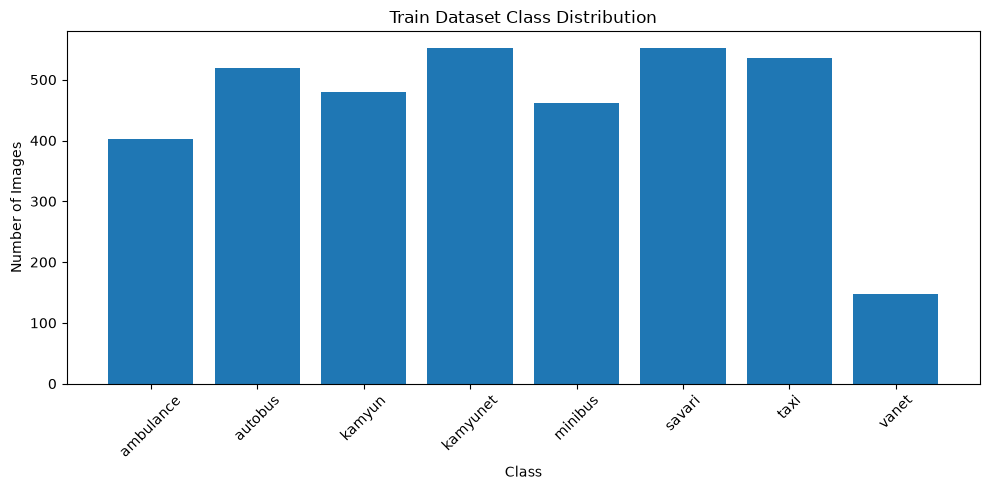

In [39]:

dataset = datasets.ImageFolder(train_path)

class_counts = Counter(dataset.targets)

classes = dataset.classes
print(classes)
counts = []

for i in range(len(classes)):
    counts.append(class_counts[i])


total = len(dataset)

for i in range(len(classes)):
    percentage = (counts[i] / total) * 100

    print(f"{classes[i]} {counts[i]} images ({percentage:.2f}%)")


plt.figure(figsize=(10, 5))

plt.bar(classes, counts)

plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Train Dataset Class Distribution")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [40]:

def inspect_images(folder_path):

    formats = Counter()
    sizes = Counter()
    modes = Counter()

    for image_path in folder_path.rglob("*"):

        if image_path.is_file():

            try:
                with Image.open(image_path) as image:

                    formats[image.format] += 1
                    sizes[image.size] += 1
                    modes[image.mode] += 1

            except Exception:
                pass

    return formats, sizes, modes

In [41]:
formats, sizes, modes = inspect_images(train_path)

print("Formats:")
for format_name, count in formats.items():
    print(format_name, ":", count)

print("\nModes:")
for mode, count in modes.items():
    print(mode, ":", count)

print("\nMost common sizes:")
for size, count in sizes.most_common(20):
    print(size, ":", count)

Formats:
JPEG : 3651

Modes:
RGB : 3651

Most common sizes:
(198, 264) : 133
(189, 252) : 117
(186, 252) : 110
(177, 240) : 73
(198, 252) : 73
(180, 240) : 63
(207, 276) : 58
(171, 228) : 53
(189, 240) : 45
(210, 276) : 44
(195, 264) : 41
(186, 240) : 40
(162, 216) : 35
(156, 204) : 34
(180, 228) : 30
(177, 228) : 24
(195, 252) : 24
(165, 216) : 20
(150, 192) : 19
(171, 216) : 16


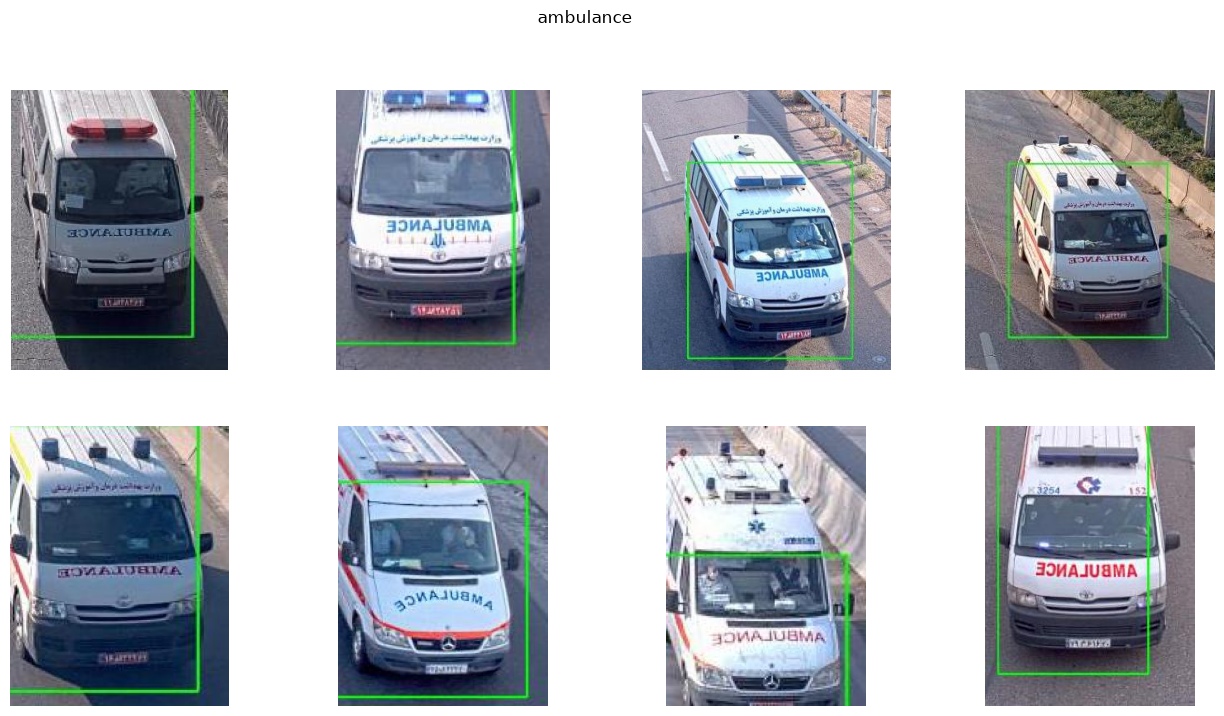

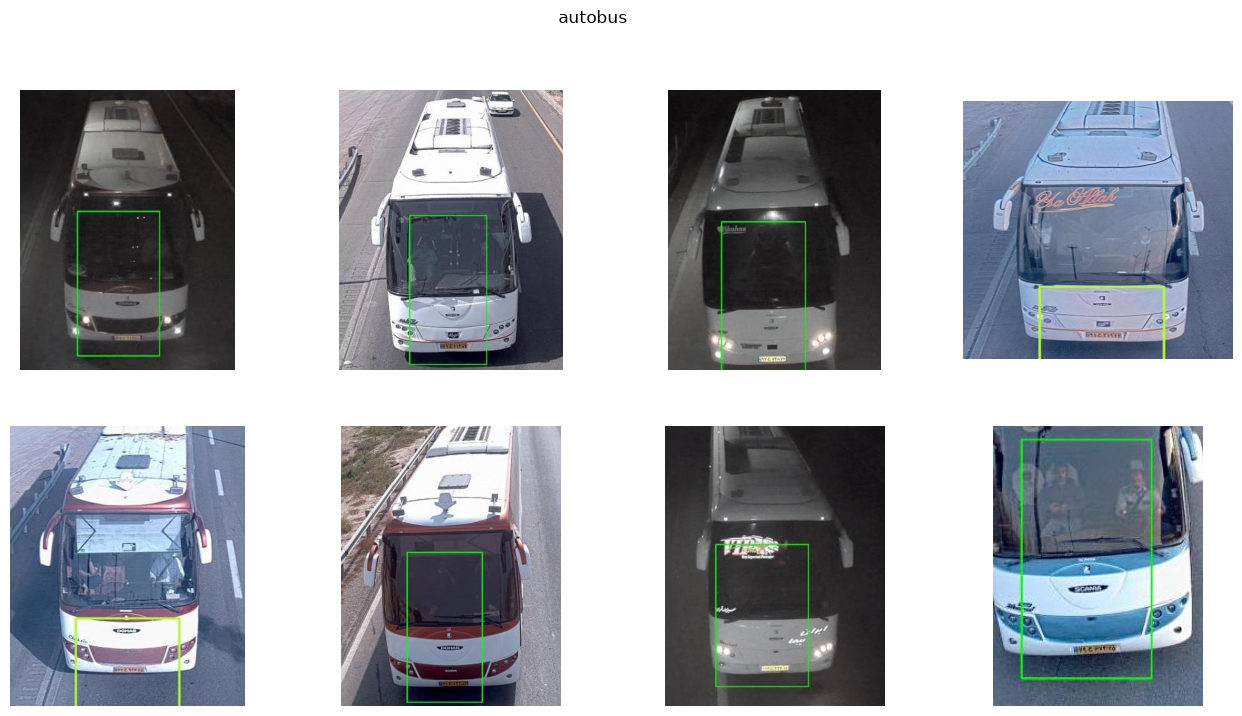

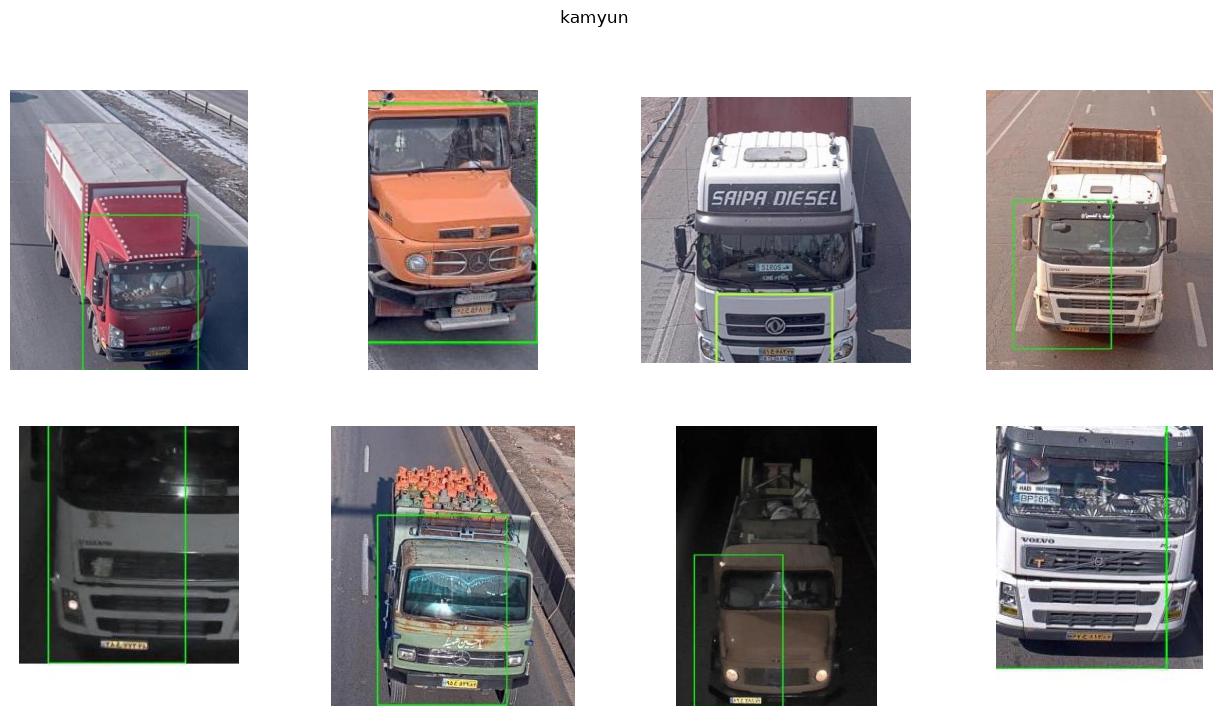

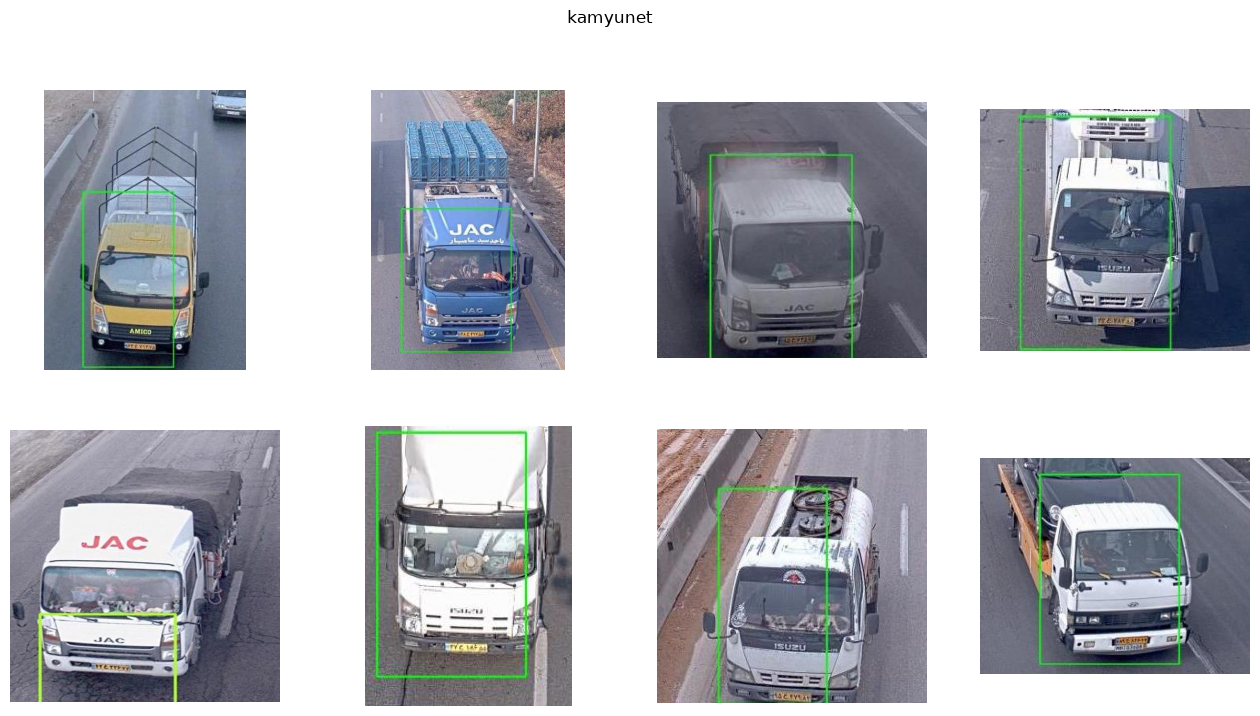

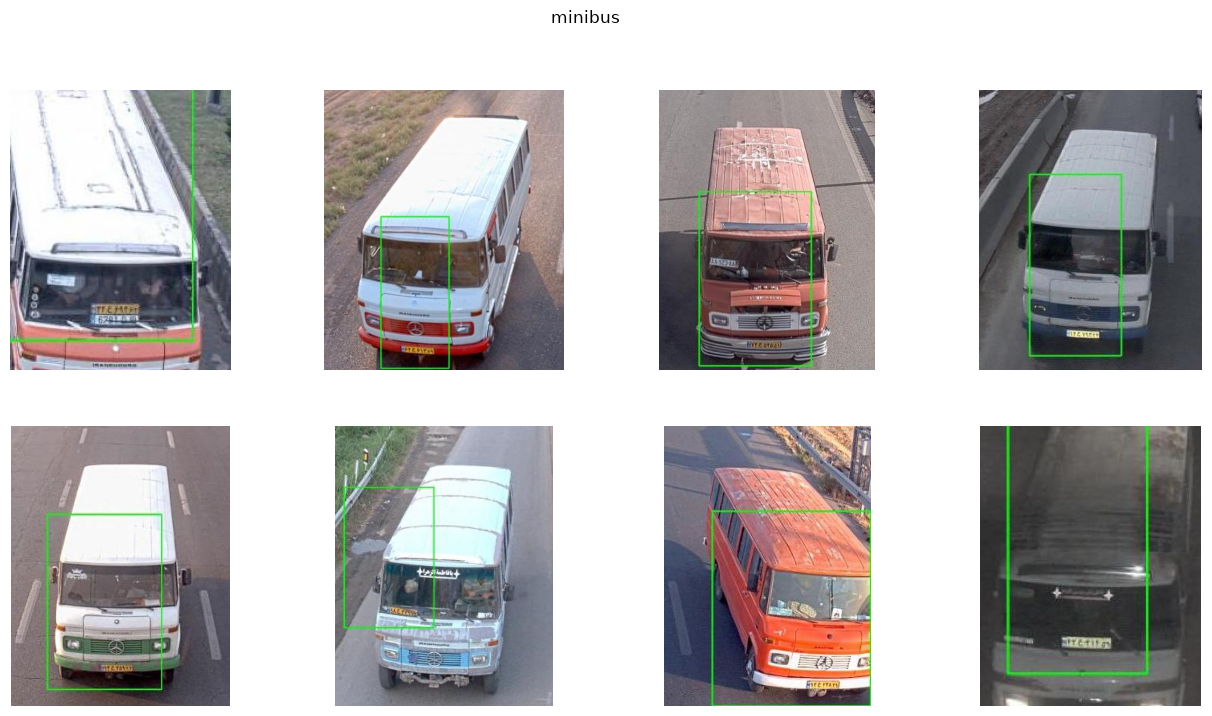

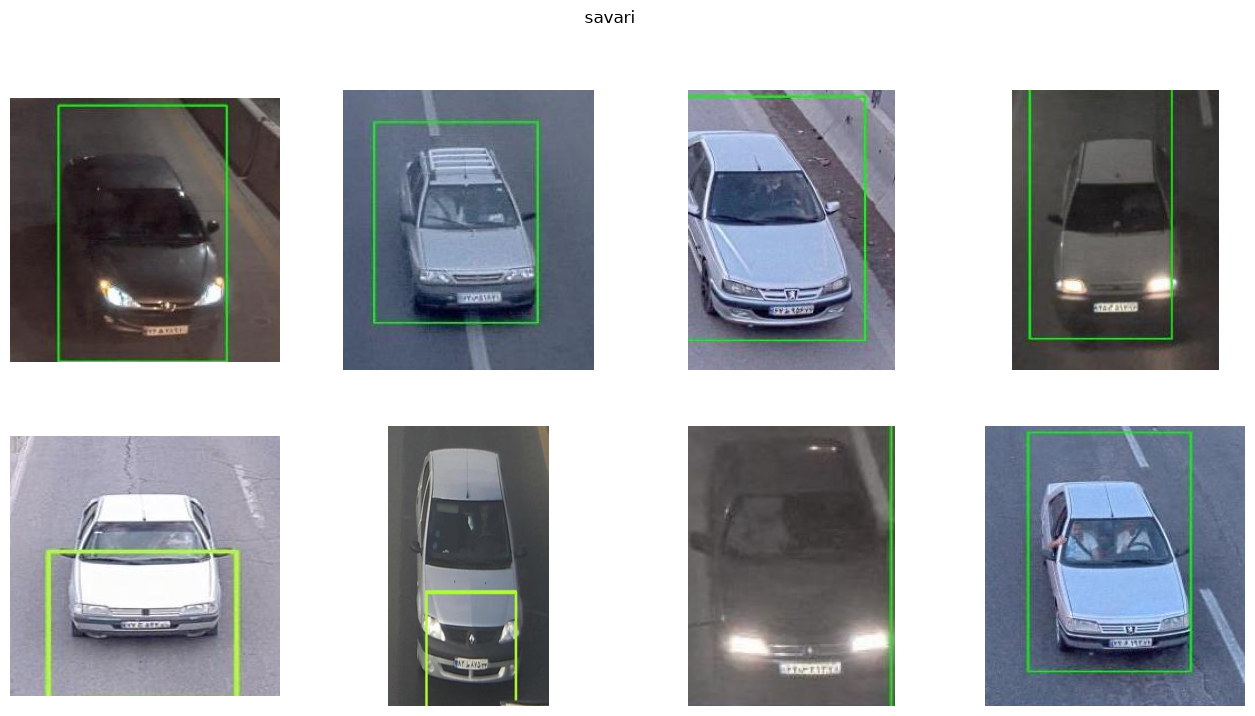

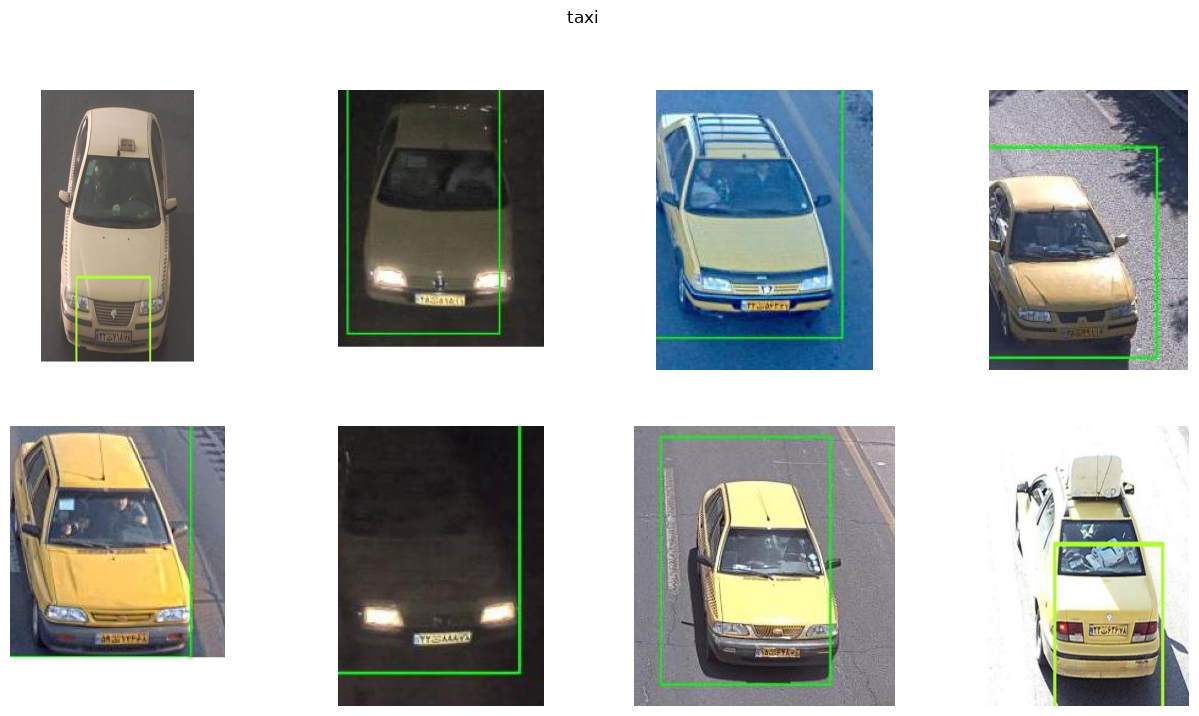

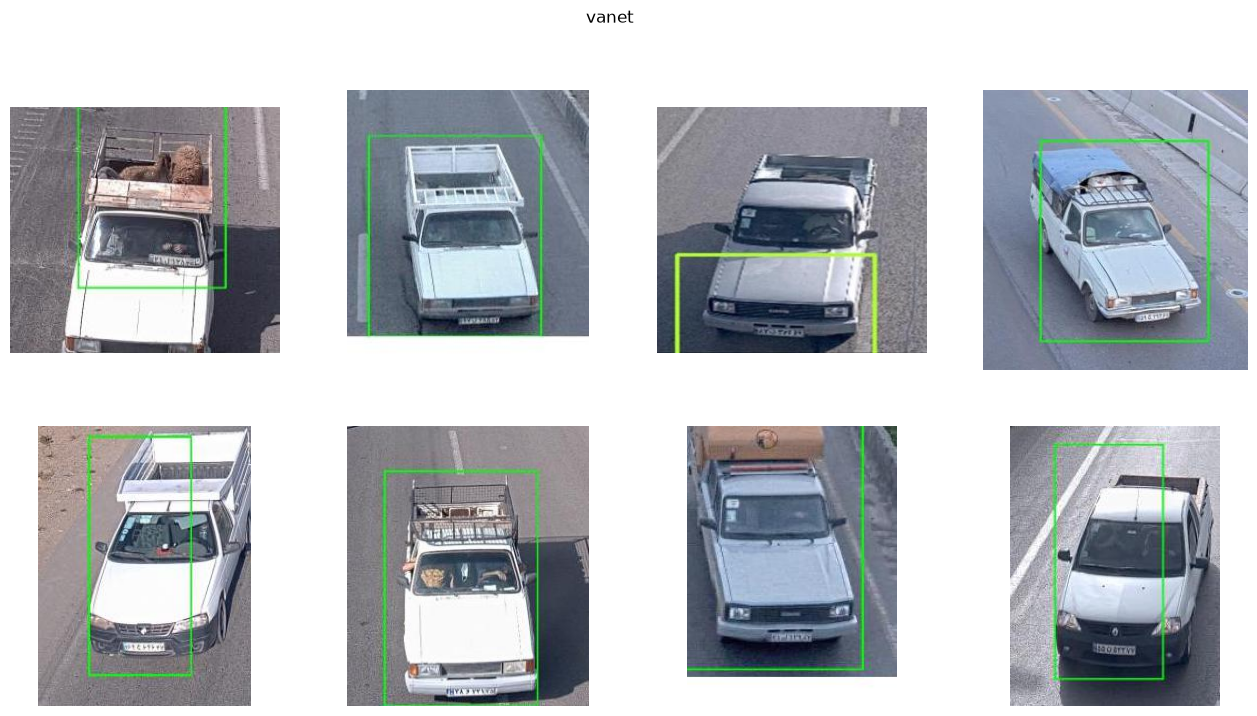

In [42]:
import random
import matplotlib.pyplot as plt
from PIL import Image

random.seed(42)

for class_path in sorted(train_path.iterdir()):

    if class_path.is_dir():

        image_files = []

        for image_path in sorted(class_path.iterdir()):
            if image_path.is_file():
                image_files.append(image_path)

        selected_images = random.sample(
            image_files,
            min(8, len(image_files))
        )

        plt.figure(figsize=(16, 8))

        for i in range(len(selected_images)):

            image = Image.open(selected_images[i])

            plt.subplot(2, 4, i + 1)
            plt.imshow(image)
            plt.axis("off")

        plt.suptitle(class_path.name)
        plt.show()

In [45]:
train_indices, val_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    random_state=42,
    stratify=dataset.targets
)

train_dataset = Subset(dataset , train_indices)
val_dataset = Subset(dataset , val_indices)

print(len(train_dataset))
print(len(val_dataset))

from collections import Counter

train_targets = []

for index in train_dataset.indices:
    train_targets.append(dataset.targets[index])

val_targets = []

for index in val_dataset.indices:
    val_targets.append(dataset.targets[index])


train_counts = Counter(train_targets)
val_counts = Counter(val_targets)

print("Train distribution:")

for i in range(len(dataset.classes)):
    count = train_counts[i]
    percentage = (count / len(train_dataset)) * 100

    print(f"{dataset.classes[i]:15} : {count:4} ({percentage:.2f}%)")


print("\nValidation distribution:")

for i in range(len(dataset.classes)):
    count = val_counts[i]
    percentage = (count / len(val_dataset)) * 100

    print(f"{dataset.classes[i]:15} : {count:4} ({percentage:.2f}%)")

2920
731
Train distribution:
ambulance       :  322 (11.03%)
autobus         :  416 (14.25%)
kamyun          :  384 (13.15%)
kamyunet        :  441 (15.10%)
minibus         :  369 (12.64%)
savari          :  441 (15.10%)
taxi            :  429 (14.69%)
vanet           :  118 (4.04%)

Validation distribution:
ambulance       :   80 (10.94%)
autobus         :  104 (14.23%)
kamyun          :   96 (13.13%)
kamyunet        :  111 (15.18%)
minibus         :   92 (12.59%)
savari          :  111 (15.18%)
taxi            :  107 (14.64%)
vanet           :   30 (4.10%)
